# Correcting π in PyCBC’s CPU chi-square calculation

PyCBC checks gravitational-wave candidates by comparing their signal power across frequency bins. The CPU calculation rotates frequency-domain correlation coefficients, sums each bin, then computes:

**qᵦ(t) = Σₖ∈ᵦ corr[k] exp(2πikt/N)**; **S = Σᵦ |qᵦ|²**; **χ² = (pS − |snr|²) norm²**.

Here N is the correlation length, t a sample index, p the number of bins, and `snr` the unnormalized matched-filter sum; `norm` is its SNR normalization.

The CPU code uses `3.141592653` for π. This notebook isolates replacing that constant with double-precision `M_PI`. It tests actual compiled kernels, first against exact answers and then on a recorded detector-data calculation. No FFT is performed inside this CPU routine.

## Run the comparison

Run from this directory with PyCBC, NumPy, Matplotlib, Cython and a C++ compiler installed. The adjacent helper compiles the archived upstream and patched kernels once, using identical compiler flags; subsequent runs reuse the build. The rest of PyCBC comes from the installed environment. **Restart Kernel and Run All**.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio:")

import sys
import numpy as np
import matplotlib.pyplot as plt
from pycbc.types import Array
from cpu_chisq_review import kernels, load_capture, reference_power, plot_style

plot_style()
cpu = kernels(('upstream', 'pi'))
variants = ("upstream", "pi")
labels = {"upstream": "Upstream", "pi": "Full-precision π"}
colors = {"upstream": "#245885", "pi": "#B77818"}
print(f"Python {sys.version.split()[0]} | NumPy {np.__version__}")
print("CPU source: gwastro/pycbc@454ee900e (2026-09-22 upstream snapshot)")

Compiling archived CPU kernels once; build log: /var/folders/l0/3dr1pyw15ln58b6xh74j_41w0000gn/T/pycbc-chisq-review-9a7d172a5a5e13f8/build.log


Python 3.13.7 | NumPy 2.3.5
CPU source: gwastro/pycbc@454ee900e (2026-09-22 upstream snapshot)


## A four-element example with an exact answer

For `corr = [1, 1, 0, 0]`, one bin containing the first two coefficients has **S(t) = 2 + 2 cos(πt/2)**. At t = 1, S is exactly 2. Complex128 uses 64-bit real and imaginary components, making the constant’s effect visible above arithmetic rounding.

In [2]:
corr = Array(np.array([1, 1, 0, 0], dtype=np.complex128))
points = np.array([0., 0.5, 1.])
expected = np.array([4., 2 + np.sqrt(2), 2.])
small = {name: cpu[name].shift_sum(corr, points, [0, 2]) for name in variants}
print("sample     exact power        upstream − exact        fixed − exact")
for j, point in enumerate(points):
    print(f"{point:5.1f}  {expected[j]:17.13f}  "
          f"{small['upstream'][j] - expected[j]:+20.12e}  "
          f"{small['pi'][j] - expected[j]:+20.12e}")
np.testing.assert_allclose(small["pi"], expected, rtol=0, atol=5e-14)
assert abs(small["upstream"][-1] - 2) > 1e-11

sample     exact power        upstream − exact        fixed − exact
  0.0    4.0000000000000   +0.000000000000e+00   +0.000000000000e+00
  0.5    3.4142135623731   +2.085225325743e-10   -4.440892098501e-16
  1.0    2.0000000000000   +5.897931032450e-10   -2.220446049250e-16


## Wider bins accumulate the angular bias

Hold N = 2²⁰ and t = N/4 fixed. Put unit coefficients at frequencies 0 and w−1; choose bin widths w divisible by four. Exact rotations give **q = 1 − i**, so **S = 2** at every width. A common initial phase cancels in power; biased relative rotations within the bin cause the discrepancy.

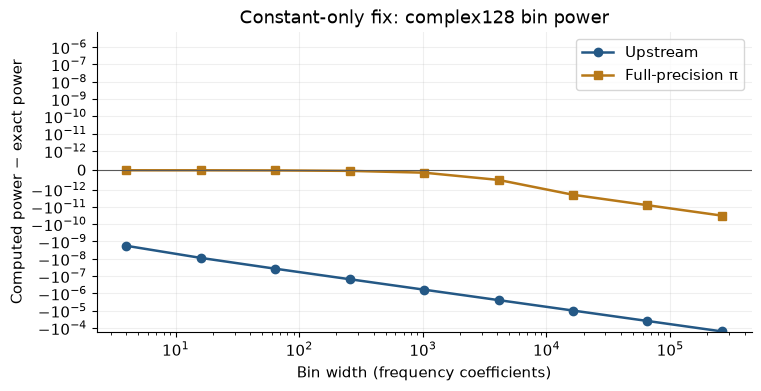

Upstream at width 262144: error -1.546101653744e-04
Full-precision π at width 262144: error -3.210320898006e-11


In [3]:
n = 2**20
widths = 4 ** np.arange(1, 10)
width_error = {name: [] for name in variants}
for width in widths:
    values = np.zeros(n, dtype=np.complex128)
    values[0] = values[width - 1] = 1
    correlation = Array(values, copy=False)
    for name in variants:
        result = cpu[name].shift_sum(correlation, [n // 4], [0, int(width)])[0]
        width_error[name].append(result - 2.)
np.testing.assert_allclose(width_error["pi"], 0, rtol=0, atol=1e-9)

fig, ax = plt.subplots(figsize=(7.5, 3.8), constrained_layout=True)
for name, marker in zip(variants, ("o", "s")):
    ax.plot(widths, width_error[name], marker=marker, color=colors[name], label=labels[name])
ax.axhline(0, color="0.35", linewidth=0.8)
ax.set(xscale="log", xlabel="Bin width (frequency coefficients)",
       ylabel="Computed power − exact power", title="Constant-only fix: complex128 bin power")
ax.set_yscale("symlog", linthresh=1e-12)
ax.legend()
plt.show()
for name in variants:
    print(f"{labels[name]} at width {widths[-1]}: error {width_error[name][-1]:+.12e}")

## Replay a calculation from LIGO Hanford data

The saved complex64 input comes from public H1 strain, a 32-template IMRPhenomD search, 2048 Hz sampling, 512-second segments and 16 bins. It was selected for a large discrepancy among six captured calls, not as a representative sample. [Capture provenance](../data/point-input-05.json).

Compare all three saved times with an independent direct Fourier sum. Hold the captured SNR power fixed and evaluate the final χ² expression in float64, isolating changes in S. The complex128 replay is a diagnostic promotion of the same stored coefficients; it cannot recover precision lost before capture. **The patch changes π only and does not promote production inputs.**

In [4]:
capture = load_capture()
indices = np.asarray(capture["indices"])
bins = np.asarray(capture["bins"])
p = len(bins) - 1
norm = float(np.asarray(capture["norm"]).reshape(()))
snr = np.asarray(capture["snr"])
snr_power = (snr.conj() * snr).real.astype(np.float64)
reference_s = reference_power(capture["corr"], indices, bins)
reference_chisq = (p * reference_s - snr_power) * norm**2
assert np.all(reference_chisq > 0)
errors = {}
for dtype in (np.complex64, np.complex128):
    correlation = Array(np.asarray(capture["corr"]).astype(dtype), copy=False)
    for name in variants:
        power = cpu[name].shift_sum(correlation, indices, bins).astype(np.float64)
        chisq = (p * power - snr_power) * norm**2
        errors[dtype.__name__, name] = 100 * (chisq - reference_chisq) / reference_chisq
print("sample      upstream c64 %    fixed c64 %   upstream c128 %   fixed c128 %")
for j, index in enumerate(indices):
    values = [errors[dtype, name][j]
              for dtype in ("complex64", "complex128") for name in variants]
    print(f"{index:6d}  " + "  ".join(f"{value:+15.8g}" for value in values))

sample      upstream c64 %    fixed c64 %   upstream c128 %   fixed c128 %
484954     -0.028173866     -0.028545297   -0.00017485401    -1.684573e-10
619888      -0.15035331       -0.1492935   -0.00022960516   +1.2366074e-10
656106      +0.17215985      +0.17388781   +0.00049974241   +4.8536673e-11


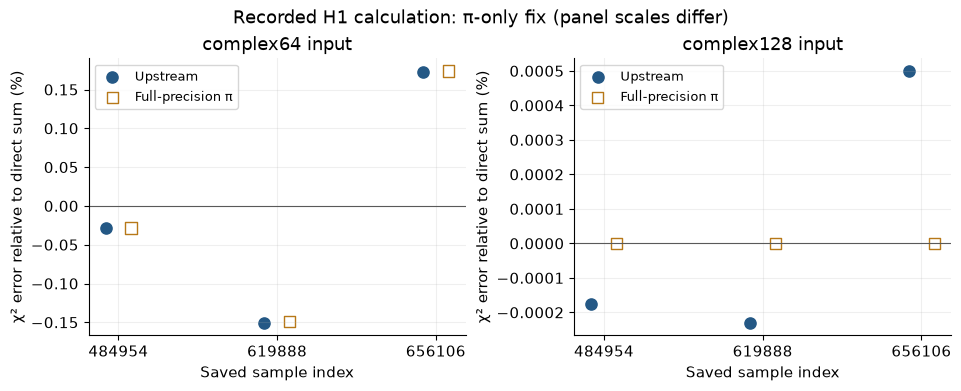

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), constrained_layout=True)
x = np.arange(len(indices))
for ax, dtype in zip(axes, ("complex64", "complex128")):
    for name, marker, offset in zip(variants, ("o", "s"), (-0.08, 0.08)):
        ax.scatter(x + offset, errors[dtype, name], color=colors[name], marker=marker,
                   facecolors=colors[name] if name == "upstream" else "none",
                   s=65, label=labels[name])
    ax.axhline(0, color="0.35", linewidth=0.8)
    ax.set_xticks(x, [str(index) for index in indices])
    ax.set(title=dtype + " input", xlabel="Saved sample index",
           ylabel="χ² error relative to direct sum (%)")
    ax.legend(fontsize=9)
fig.suptitle("Recorded H1 calculation: π-only fix (panel scales differ)")
plt.show()

The promoted complex128 comparison exposes the π correction. With the captured complex64 dtype, phase rotations and sums round to float32; changing π can interact with that rounding and need not improve every sample. χ² can affect candidate ranking, but this selected replay does not establish changes in search sensitivity, rankings or false-alarm rates.